# Defensa Final - Caso Integrador

**Predicción de abandono en una academia online (pandas + sklearn + TF)**

> Generado desde [Kobalto Cursos](https://kobalto.com) - 17/6/2026

## Setup

Importación de librerías necesarias:

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

## Carga de Datos

Ejecuta esta celda para cargar el dataset:

In [59]:
import pandas as pd
import numpy as np

# Dataset sintético: alumnos de una academia online (primeras 4 semanas)
# Cada alumno tiene un perfil + comportamiento + un target abandono.
np.random.seed(42)
n = 1200

edad = np.clip(np.random.normal(28, 7, n), 16, 60).round(0).astype(int)
nivel_previo = np.random.choice(['ninguno', 'basico', 'medio', 'avanzado'], size=n, p=[0.45, 0.30, 0.18, 0.07])
modalidad = np.random.choice(['part_time', 'full_time'], size=n, p=[0.62, 0.38])
horas_semana = np.clip(np.random.normal(8, 4, n), 0, 30).round(1)
ejercicios_completados = np.clip(np.random.poisson(12, n), 0, 60)
notas_avg = np.clip(np.random.normal(6.5, 1.8, n), 0, 10).round(1)
asistencias_directos = np.clip(np.random.poisson(3, n), 0, 12)
preguntas_foro = np.clip(np.random.poisson(2, n), 0, 30)
dias_desde_ultima_conexion = np.clip(np.random.exponential(4, n), 0, 30).round(0).astype(int)

# Probabilidad de abandono modelada con señales realistas
prob = 0.18
prob = prob + np.where(horas_semana < 4, 0.30, 0.0)
prob = prob + np.where(ejercicios_completados < 5, 0.25, 0.0)
prob = prob + np.where(dias_desde_ultima_conexion > 7, 0.30, 0.0)
prob = prob + np.where(notas_avg < 5, 0.20, 0.0)
prob = prob - np.where(asistencias_directos >= 4, 0.15, 0.0)
prob = prob - np.where(preguntas_foro >= 3, 0.10, 0.0)
prob = prob + np.where(nivel_previo == 'ninguno', 0.05, 0.0)
prob = np.clip(prob, 0.02, 0.95)
abandono = (np.random.random(n) < prob).astype(int)

# Introducimos huecos realistas
notas_avg_nan = notas_avg.copy()
notas_avg_nan[np.random.choice(n, size=64, replace=False)] = np.nan
nivel_previo_nan = nivel_previo.copy().astype(object)
nivel_previo_nan[np.random.choice(n, size=18, replace=False)] = np.nan

df = pd.DataFrame({
    'alumno_id': range(1, n+1),
    'edad': edad,
    'nivel_previo': nivel_previo_nan,
    'modalidad': modalidad,
    'horas_semana': horas_semana,
    'ejercicios_completados': ejercicios_completados,
    'notas_avg': notas_avg_nan,
    'asistencias_directos': asistencias_directos,
    'preguntas_foro': preguntas_foro,
    'dias_desde_ultima_conexion': dias_desde_ultima_conexion,
    'abandono': abandono,
})

print(f"Dataset cargado: {df.shape[0]} alumnos, {df.shape[1]} columnas")
print(f"Tasa de abandono: {df['abandono'].mean():.1%}")
print(f"\nValores nulos:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Dataset cargado: 1200 alumnos, 11 columnas
Tasa de abandono: 24.8%

Valores nulos:
nivel_previo    18
notas_avg       64
dtype: int64


## Ejercicio 1: Exploración inicial (EDA)

**Objetivo:** Conocer el dataset: estructura, distribución del target y señales preliminares

Antes de modelar, audita los datos. Mira la forma, los tipos, los nulos, y cómo se distribuye el target en función de las variables principales.

### Tareas

- Mostrar df.head() y df.info() (o df.dtypes)
- Contar valores nulos por columna
- Calcular la tasa de abandono global
- Calcular tasa de abandono por nivel_previo y por modalidad con groupby
- Calcular la correlación entre horas_semana, ejercicios_completados, notas_avg y abandono

In [60]:
# TODO: Mostrar las primeras filas y la información de columnas
df.head()

,alumno_id,edad,nivel_previo,modalidad,horas_semana,ejercicios_completados,notas_avg,asistencias_directos,preguntas_foro,dias_desde_ultima_conexion,abandono
0,1,31,ninguno,full_time,6.1,10,9.5,3,1,2,0
1,2,27,basico,full_time,5.6,15,4.9,7,1,2,0
2,3,33,avanzado,part_time,10.0,16,6.8,4,4,12,0
3,4,39,basico,full_time,6.6,11,5.3,0,3,2,0
4,5,26,medio,part_time,7.4,9,7.6,2,3,9,0


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   alumno_id                   1200 non-null   int64  
 1   edad                        1200 non-null   int64  
 2   nivel_previo                1182 non-null   str    
 3   modalidad                   1200 non-null   str    
 4   horas_semana                1200 non-null   float64
 5   ejercicios_completados      1200 non-null   int32  
 6   notas_avg                   1136 non-null   float64
 7   asistencias_directos        1200 non-null   int32  
 8   preguntas_foro              1200 non-null   int32  
 9   dias_desde_ultima_conexion  1200 non-null   int64  
 10  abandono                    1200 non-null   int64  
dtypes: float64(2), int32(3), int64(4), str(2)
memory usage: 89.2 KB


In [62]:
# TODO: Contar nulos
df.isnull().sum()

alumno_id                      0
edad                           0
nivel_previo                  18
modalidad                      0
horas_semana                   0
ejercicios_completados         0
notas_avg                     64
asistencias_directos           0
preguntas_foro                 0
dias_desde_ultima_conexion     0
abandono                       0
dtype: int64

In [63]:
# TODO: Tasa de abandono global
print(f"Tasa de abandono: {df['abandono'].mean():.2%}")

Tasa de abandono: 24.75%


In [64]:
# TODO: Tasa de abandono por nivel_previo y por modalidad
print('** Tasa de abandono por nivel previo **')
print(df.groupby('nivel_previo')['abandono'].mean().round(3))

print('\n** Tasa de abandono por modalidad **')
print(df.groupby('modalidad')['abandono'].mean().round(3))

** Tasa de abandono por nivel previo **
nivel_previo
avanzado    0.165
basico      0.232
medio       0.290
ninguno     0.256
Name: abandono, dtype: float64

** Tasa de abandono por modalidad **
modalidad
full_time    0.248
part_time    0.247
Name: abandono, dtype: float64


In [65]:
# TODO: Correlación entre features numéricas y abandono
df[['horas_semana','ejercicios_completados','notas_avg','dias_desde_ultima_conexion','abandono']].corr().round(2)

,horas_semana,ejercicios_completados,notas_avg,dias_desde_ultima_conexion,abandono
horas_semana,1.00,-0.00,-0.04,-0.00,-0.12
ejercicios_completados,-0.00,1.00,0.06,0.05,-0.02
notas_avg,-0.04,0.06,1.00,0.03,-0.11
dias_desde_ultima_conexion,-0.00,0.05,0.03,1.00,0.20
abandono,-0.12,-0.02,-0.11,0.20,1.00


---

## Ejercicio 2: Visualización: tres gráficos justificados

**Objetivo:** Construir tres visualizaciones que comuniquen hallazgos relevantes para negocio

Cada gráfico debe responder a una pregunta concreta. Los gráficos decorativos no cuentan: cada uno debe defender una afirmación que harás luego en la discusión.

### Tareas

- Histograma de horas_semana coloreado por abandono (0 vs 1)
- Boxplot de notas_avg por nivel_previo
- Barras: tasa de abandono por bucket de dias_desde_ultima_conexion (0-1, 2-4, 5-7, 8+)
- Añadir título, etiquetas y leyenda a cada gráfico

Gráficos generados


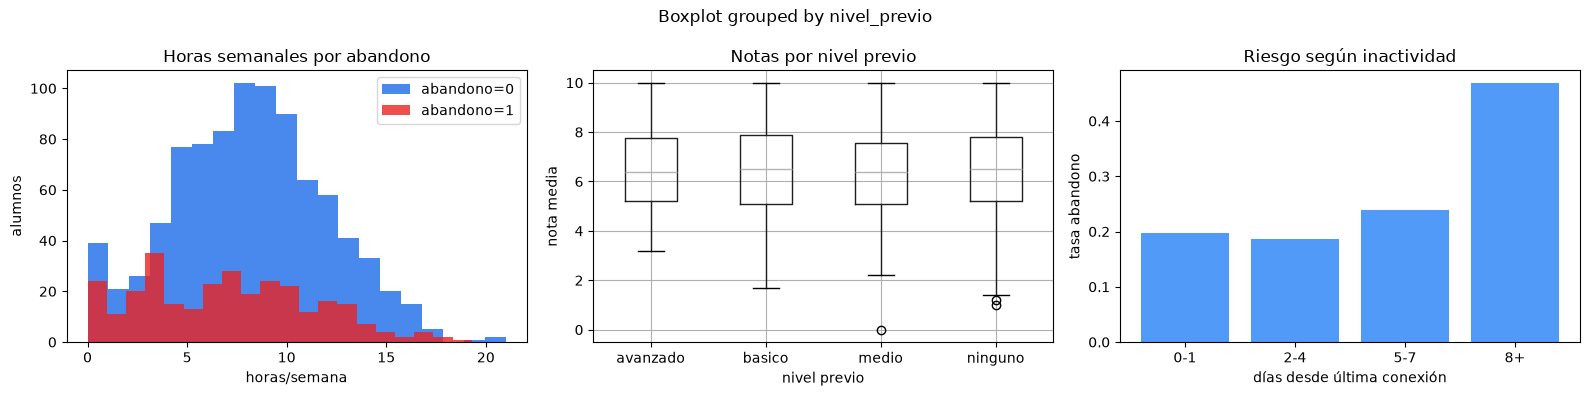

In [66]:
# EJERCICIO 2: Tres gráficos justificados
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# TODO 1: Histograma de horas_semana coloreado por abandono
for t, color in [(0, "#1b6ae9"), (1, "#e92323")]:
    axes[0].hist(df[df['abandono']==t]['horas_semana'], bins=20, alpha=0.8, label=f'abandono={t}', color=color)
    axes[0].set_xlabel('horas/semana'); axes[0].set_ylabel('alumnos')
    axes[0].set_title('Horas semanales por abandono'); axes[0].legend()

# TODO 2: Boxplot de notas_avg por nivel_previo
df.boxplot(column='notas_avg', by='nivel_previo', ax=axes[1])
axes[1].set_title('Notas por nivel previo'); axes[1].set_xlabel('nivel previo'); axes[1].set_ylabel('nota media')

# TODO 3: Tasa de abandono por bucket de dias_desde_ultima_conexion
buckets = pd.cut(df['dias_desde_ultima_conexion'], bins=[-1,1,4,7,40], labels=['0-1','2-4','5-7','8+'])
tasa = df.groupby(buckets)['abandono'].mean()
axes[2].bar(tasa.index.astype(str), tasa.values, color="#529af8")
axes[2].set_xlabel('días desde última conexión'); axes[2].set_ylabel('tasa abandono')
axes[2].set_title('Riesgo según inactividad')

plt.tight_layout()
plt.savefig('eda.png', dpi=80)
print('Gráficos generados')

---

## Ejercicio 3: Preprocesado + split estratificado

**Objetivo:** Imputar nulos, codificar categóricas, escalar numéricas y partir train/test sin fugas

Crea un ColumnTransformer que combine pipelines numérico y categórico. Después haz el split estratificado por la variable objetivo.

### Tareas

- Definir features numéricas y categóricas explícitamente
- Pipeline numérico: SimpleImputer(strategy='median') + StandardScaler
- Pipeline categórico: SimpleImputer(strategy='most_frequent') + OneHotEncoder(handle_unknown='ignore')
- Combinar con ColumnTransformer
- Split estratificado: test_size=0.2, random_state=42, stratify=y

In [67]:
# EJERCICIO 3: Preprocesado + Split estratificado
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

num_features = ['edad','horas_semana','ejercicios_completados','notas_avg','asistencias_directos','preguntas_foro','dias_desde_ultima_conexion']
cat_features = ['nivel_previo','modalidad']

# TODO: Pipeline numérico
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# TODO: Pipeline categórico
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# TODO: ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

X = df[num_features + cat_features]
y = df['abandono']

# TODO: Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("** Tamaño del split **")
print(f"  Train: {len(X_train)} muestras")
print(f"  Test:  {len(X_test)} muestras")
print()
print("** Tasa de abandono **")
print(f"  Train: {y_train.mean():.2%}")
print(f"  Test:  {y_test.mean():.2%}")

** Tamaño del split **
  Train: 960 muestras
  Test:  240 muestras

** Tasa de abandono **
  Train: 24.79%
  Test:  24.58%


---

## Ejercicio 4: Baseline sklearn: LogReg + RandomForest

**Objetivo:** Entrenar dos modelos clásicos y compararlos en accuracy y F1 sobre test

Antes de tirar de redes neuronales, establece un baseline sólido. Una regresión logística rápida y un RandomForest no lineal te dan suelo y techo de lo que se puede esperar con métodos clásicos.

### Tareas

- Pipeline preprocessor + LogisticRegression(max_iter=1000, random_state=42)
- Pipeline preprocessor + RandomForestClassifier(n_estimators=200, random_state=42)
- Entrenar ambos con X_train, y_train
- Calcular accuracy + f1_score sobre X_test
- Mostrar classification_report del mejor de los dos

In [68]:
# EJERCICIO 4: Baseline sklearn (LogReg + RandomForest)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Definir modelos en un diccionario
modelos = {
    'logreg': LogisticRegression(max_iter=1000, random_state=42),
    'rfc': RandomForestClassifier(n_estimators=200, random_state=42)
}

# TODO: Bucle: entrenar cada uno y guardar acc + f1 + pipe + y_pred
resultados = {}
for nombre, clf in modelos.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    resultados[nombre] = {'acc': acc, 'f1': f1, 'pipe': pipe, 'y_pred': y_pred}
    print(f"{nombre}: accuracy={acc:.3f}  F1={f1:.3f}")

# TODO: Elegir el mejor por F1 y mostrar classification_report
mejor = max(resultados, key=lambda k: resultados[k]['f1'])
print(f"\nMejor por F1: {mejor}")
print(classification_report(y_test, resultados[mejor]['y_pred'], digits=3))

logreg: accuracy=0.758  F1=0.216
rfc: accuracy=0.729  F1=0.156

Mejor por F1: logreg
              precision    recall  f1-score   support

           0      0.773     0.961     0.857       181
           1      0.533     0.136     0.216        59

    accuracy                          0.758       240
   macro avg      0.653     0.548     0.537       240
weighted avg      0.714     0.758     0.700       240



---

## Ejercicio 5: Matriz de confusión y decisión de negocio

**Objetivo:** Interpretar TP/FP/TN/FN del mejor modelo y traducirlos a coste de negocio

El accuracy no captura el coste real de los errores. Mira la matriz de confusión, identifica falsos positivos y falsos negativos y decide cuál es más caro para la academia.

### Tareas

- Calcular confusion_matrix del mejor modelo del ejercicio anterior
- Mostrar etiquetada: TN, FP, FN, TP
- Calcular precision, recall y F1 manualmente desde la matriz
- Verificar que coinciden con los de classification_report

In [69]:
# EJERCICIO 5: Matriz de confusión y decisión de negocio
from sklearn.metrics import confusion_matrix

# TODO: Calcular matriz de confusión del mejor modelo
y_pred_mejor = resultados[mejor]['y_pred']
cm = confusion_matrix(y_test, y_pred_mejor)
print('Matriz de confusión:')
print(cm)

# TODO: Extraer tn, fp, fn, tp
tn, fp, fn, tp = cm.ravel()
print(f"\nTP={tp} FP={fp} TN={tn} FN={fn}")

# TODO: Calcular precision, recall y F1 manualmente
precision = tp/(tp+fp) if (tp+fp) else 0
recall = tp/(tp+fn) if (tp+fn) else 0
f1 = 2*precision*recall/(precision+recall) if (precision+recall) else 0
print(f"\nprecision={precision:.3f}  recall={recall:.3f}  F1={f1:.3f}")

# TODO: Verificar que coinciden con classification_report
print(classification_report(y_test, y_pred_mejor, digits=3))

Matriz de confusión:
[[174   7]
 [ 51   8]]

TP=8 FP=7 TN=174 FN=51

precision=0.533  recall=0.136  F1=0.216
              precision    recall  f1-score   support

           0      0.773     0.961     0.857       181
           1      0.533     0.136     0.216        59

    accuracy                          0.758       240
   macro avg      0.653     0.548     0.537       240
weighted avg      0.714     0.758     0.700       240



---

## Ejercicio 6: Red neuronal con TensorFlow (Sequential)

**Objetivo:** Construir una red neuronal densa con la API Sequential de Keras y entrenarla sobre el dataset preprocesado

Usa solo la API Sequential del Tema 1 de TensorFlow: capas Dense, activaciones relu/sigmoid, compile + fit. No necesitas callbacks ni regularización avanzada. El objetivo es demostrar que sabes traducir el problema a una red neuronal, no batir al baseline.

### Tareas

- Transformar X_train y X_test con preprocessor.fit_transform / transform para obtener arrays numéricos densos
- Crear un Sequential con: Dense(32, activation="relu", input_shape=(n_features,)), Dense(16, activation="relu"), Dense(1, activation="sigmoid")
- Compilar con optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
- Entrenar con fit(X_train_proc, y_train, validation_split=0.2, epochs=20, batch_size=32, verbose=0)
- Evaluar con model.evaluate(X_test_proc, y_test) y obtener predicciones >0.5

c:\Users\frasq\Documents\GitHub\Master-IA-y-Big-Data\Tensor-Flow\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

NN test acc=0.754  F1=0.213
Curva de loss guardada


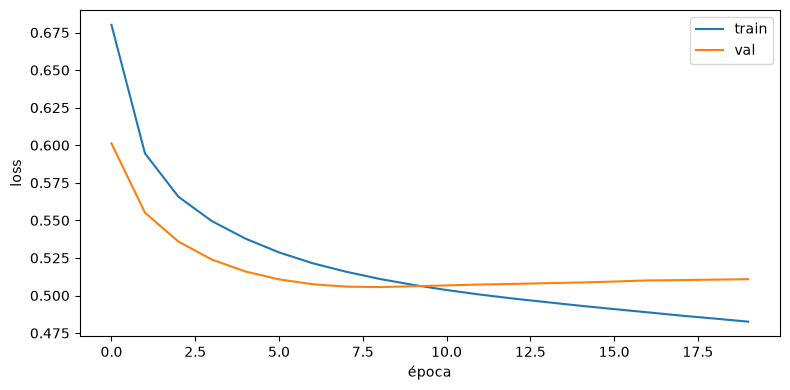

In [70]:
# EJERCICIO 6: Red neuronal Sequential (TensorFlow Tema 1)
# Nota: este ejercicio NO se ejecuta en pyodide. Cópialo a tu Jupyter local con TensorFlow instalado.

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

# TODO: Preprocesar X_train y X_test con el preprocessor (fit_transform / transform)
# Si la salida es sparse, convertir con .toarray()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
if hasattr(X_train_proc, 'toarray'):
    X_train_proc = X_train_proc.toarray()
    X_test_proc = X_test_proc.toarray()

# TODO: Construir Sequential con Dense(32, relu) → Dense(16, relu) → Dense(1, sigmoid)
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_proc.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid'),
])

# TODO: Compilar con adam + binary_crossentropy + accuracy
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# TODO: fit con validation_split=0.2, epochs=20, batch_size=32, verbose=0
history = model.fit(
    X_train_proc, y_train.values,
    validation_split=0.2, epochs=20, batch_size=32, verbose=0
)

# TODO: Evaluar en test y calcular F1
loss, acc = model.evaluate(X_test_proc, y_test.values, verbose=0)
y_pred_nn = (model.predict(X_test_proc, verbose=0) > 0.5).astype(int).ravel()
print(f"NN test acc={acc:.3f}  F1={f1_score(y_test, y_pred_nn):.3f}")

# TODO: Pintar curva de loss y val_loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('época'); plt.ylabel('loss'); plt.legend()
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=80)
print('Curva de loss guardada')

---

## Ejercicio 7: Comparativa final y discusión escrita

**Objetivo:** Cerrar el caso comparando los tres modelos y produciendo la conclusión de defensa

Construye una tabla final con los tres modelos (LogReg, RF, Red neuronal) en accuracy y F1. Responde por escrito las preguntas de la defensa. La nota de este ejercicio depende SOBRE TODO de la calidad de tus respuestas escritas.

### Tareas

- Construir un DataFrame con columnas: modelo, accuracy, F1, tiempo_estimado_inferencia
- Ordenarlo por F1 descendente
- Mostrarlo y elegir el modelo que recomendarías a la dirección
- Responder en celdas de markdown las preguntas escritas de defensa

In [71]:
# EJERCICIO 7: Comparativa final y defensa escrita
# Construye la tabla comparativa y RESPONDE las preguntas escritas en celdas markdown.

# TODO: Construir DataFrame con modelo, accuracy, F1
# TODO: Ordenar por F1 descendente
# TODO: Mostrar la tabla
# TODO: Imprimir la recomendación final
comparativa = pd.DataFrame([
    {'modelo':'LogisticRegression', 'accuracy':resultados['logreg']['acc'], 'F1':resultados['logreg']['f1']},
    {'modelo':'RandomForest', 'accuracy':resultados['rfc']['acc'], 'F1':resultados['rfc']['f1']},
    {'modelo':'NN_Sequential', 'accuracy':acc, 'F1':f1_score(y_test, y_pred_nn)},
]).sort_values('F1', ascending=False).reset_index(drop=True)
print(comparativa.round(3))
print(f"\nRecomendación a dirección: {comparativa.iloc[0]['modelo']}")

# --- RESPUESTAS ESCRITAS ---
# Convierte las navigatorQuestions de arriba en celdas markdown del notebook.
# La nota de este ejercicio se basa fundamentalmente en la calidad de tus respuestas.

               modelo  accuracy     F1
0  LogisticRegression     0.758  0.216
1       NN_Sequential     0.754  0.213
2        RandomForest     0.729  0.156

Recomendación a dirección: LogisticRegression


### **Respuestas Escritas**

#### Ejercicio 1 ¿Qué variable tiene mayor correlación con el abandono según el EDA?

`dias_desde_ultima_conexion` es la variable más correlacionada con el abandono (r = 0.20).

#### Ejercicio 2 ¿Qué afirmación de negocio defiende cada gráfico?

El histograma de `horas_semana` muestra que los alumnos con menos de 4 h por semana tienen la mayoría de los abandonos.
El boxplot de `notas_avg` muestra que los alumnos de nivel "medio" tienen la media de notas más bajas y disperas que el resto de grupos.
El gráfico de barras de inactividad muestra que a partir del bucket "+8 días" la tasa de abandono se dispara.

#### Ejercicio 3 ¿Por qué el split es estratificado y qué problema previene?

Con una tasa de abandono del 24,8 %, un split aleatorio podría generar un test con un 15 % o un 35 % de positivos por aleatoriedad. 
`stratify=y` garantiza que train y test tengan la misma proporción de abandonos (≈24,8 %) y que las comparaciones entre modelos sean justas.

#### Ejercicio 4 ¿Por qué RandomForest obtiene peor F1 que LogReg siendo un modelo más complejo?

Con 1.200 muestras y 300 abandonos, RandomForest tiende a sobreajustarse.
LogReg, al ser un modelo más simple generaliza mejor con pocos datos.

#### Ejercicio 5 ¿Qué revelan los 51 FN y qué implicación tiene para el negocio?

51 FN significa que el modelo deja pasar sin detectar al 86 % de los alumnos que realmente abandonan.
En términos de coste, cada FP tiene un coste muy bajo. 
El modelo en su estado actual no es útil para intervención proactiva; necesita aumentar el recall aunque baje la precisión.